In [23]:
import numpy as np
import matplotlib.pyplot as plt

Nc=3
Cf=(Nc**2-1)/(2*Nc)

In [24]:
def DipoleS(r, Qs=np.sqrt(0.104), log=True):
    """Dipole S matrix."""
    result =  -(r**2 * Qs**2) / 4  * np.log(1/(r*0.241+1e-10) + np.e)
    if log:
        return result 
    else:
        return np.exp(result)
    




In [25]:
import pdb

Note about notation: $S = e^{-C_F/2 \Gamma}$, and $\Gamma = \mu^2 (-2L)$ (dropping cancelling infinities) This gives $L = -\Gamma/(2\mu^2) = -\ln S/(C_F/2) \cdot 1/(-2\mu^2) =\frac{1}{C_F} \ln S$



In [51]:
# F(p1,p2,p3,p4) blow (B13)
def F(x1,x2,x2p,x1p, print_norms=False):

        if print_norms:
            print(np.linalg.norm(x1-x2p), np.linalg.norm(x2-x1p), np.linalg.norm(x1-x1p), np.linalg.norm(x2-x2p))


        # Note: I'm not sure why I need the minus sign in front?
        return  1/Cf*(DipoleS(np.linalg.norm(x1-x2p),log=True) + DipoleS(np.linalg.norm(x2-x1p),log=True)  \
                - DipoleS(np.linalg.norm(x1-x1p),log=True) - DipoleS(np.linalg.norm(x2-x2p),log=True)  )


def Quadrupole(x1,x2,x2p,x1p, largeNc=False):
    '''Compute quadrupole following Dominguez et al, we also adapt their notation to avoid typos
    Q(x1,x2,x2p,x1p) = 1/nc Tr(V(x1)V^d(x1p)V(x2p)V^d(x2))
    Here x1,x2,x2p,x1p are 2d vectors!
    Note: in Schenke, Lappi https://arxiv.org/pdf/1108.4764 notation this is different!
    '''

# see also 1112.1104 eq 4.27 
 # they define Q_1234 = 1/Nr (Tr V_x1^dg V_x2 V_x3^dg V_x4)
 # in our notation that is Q(x1,x2,x2p,x1p)
 # sec 2.3: there is a mirror symmetry Q_(1234)=Q_(1432) 
 # i.e. in our notation Q(x1,x2,x2p,x1p) = Q(x1,x1p,x2p,x2)
 

# and https://arxiv.org/pdf/hep-ph/0405266  eq 14


    x1=np.array(x1)
    x2=np.array(x2)
    x2p=np.array(x2p)
    x1p=np.array(x1p)    

    f1 = F(x1,x2,x2p,x1p)
    f2 = F(x1,x2p,x2,x1p)

    # print(f"F1 = {f2}")
    # print(f"F2 = {f1}")

    if largeNc or True :
        dip1 = DipoleS(np.linalg.norm(x1-x2),log=False)
        dip2 = DipoleS(np.linalg.norm(x2p-x1p),log=False)

        dip3 = DipoleS(np.linalg.norm(x1-x1p),log=False)
        dip4 = DipoleS(np.linalg.norm(x2-x2p),log=False)

        r = f1/f2
        
        if f2 == 0 and largeNc:
            print("Not sure I can trust this!")

        if largeNc:
            return dip1*dip2 - r*(dip1*dip2 - dip3*dip4)


    f3 = F(x1,x1p,x2p,x2)
    # print(f"F3 = {f3}")
    
    sqrtDelta = np.sqrt(f2**2 + 4./Nc**2*f1*f3)
    #print(sqrtDelta)

    # (B21)
    fact1 = ( (sqrtDelta+F(x1,x2p,x2,x1p))/(2*sqrtDelta) - F(x1,x2,x2p,x1p)/sqrtDelta ) * np.exp(Nc/4.*sqrtDelta)
    fact2 = ( (sqrtDelta-F(x1,x2p,x2,x1p))/(2*sqrtDelta) + F(x1,x2,x2p,x1p)/sqrtDelta ) * np.exp(-Nc/4.*sqrtDelta)
    #print(fact1 + fact2)

  

    res = DipoleS(np.linalg.norm(x1-x2),log=False) * DipoleS(np.linalg.norm(x2p-x1p),log=False) * (fact1 + fact2 ) * np.exp(-Nc/4.*F(x1,x2p,x2,x1p)+1./(2*Nc)*F(x1,x2,x2p,x1p) )

    return res

In [27]:
x1, x2, x2p, x1p = 1,2,3,4

print(Quadrupole(x1,x2,x2p,x1p))

1.108354922579568
0.862338988408845


## Tests

### Mirror symmetry

In [28]:
def TestMirror():
    # See mirror symmetry comment above 

    
    x1=np.array([1,2])
    x2=np.array([4,-1])*0.1
    x1p=np.array([-3,5])*0.1
    x2p=np.array([0,0])
    q = Quadrupole(x1, x2, x2p, x1p)
    q_mirror = Quadrupole(x1,x1p,x2p,x2)
                          
    print("FInite Nc", q, " mirror ", q_mirror)

    q_largenc = Quadrupole(x1, x2, x2p, x1p, largeNc=True)
    q_mirror_largenc = Quadrupole(x1,x1p,x2p,x2, largeNc=True)
    print("Large Nc", q_largenc, " mirror ", q_mirror_largenc)

TestMirror()

1.056958798082511
1.056958798082511
FInite Nc 0.8676757320919534  mirror  0.8676757320919533
Large Nc 0.8677855001392938  mirror  0.8677855001392938


### Coinsidence limit

In [ ]:
def TestUnity():
    '''Test case where Wilson lines are the same'''

    # x1=x1p, x2=x2p
    # In this limit we have 1/Nc Tr(1)=1
    v1=np.array([1,2])
    v2=np.array([4,-1])*0.1
    x1=v1 
    x2=v2
    x1p=x1 
    x2p=x2 

    print(F(x1,x2,x2p,x1p   ), F(x1,x2p,x2,x1))

    #print(F(x1,x2,x2p,x1p), F(x1,x1p,x2p,x2))

    #
    q = Quadrupole(x1,x2,x2p,x1p,largeNc=False)
    q_largenc = Quadrupole(x1,x2,x2p,x1p, largeNc=True)

    print("x_1=x_1', x_2=x_2', Q=",q, " Q_largeNc=", q_largenc)



    # x1=x2
    # x1p = x2p 
    x1=v1 
    x1p=v2
    x2=v1
    x1p=x2p 
    q = Quadrupole(x1,x2,x2p,x1p,largeNc=False)
    q_largenc = Quadrupole(x1,x2,x2p,x1p, largeNc=True)


    print("x_1=x_2, x_2=x_1', Q=",q, " Q_largeNc=", q_largenc)

TestUnity()

-0.2846248725342435 -0.2846248725342435
1.2379646929146675
x_1=x_1', x_2=x_2', Q= 1.0  Q_largeNc= 1.0
1.2379646929146675
x_1=x_2, x_2=x_1', Q= 1.0  Q_largeNc= 1.0


1.0624326560588906
1.0706580857045376
1.0782240529836429
1.0854571130324902
1.0925016554545164
1.0994351149803663
1.1063034689672728
1.1131359167056536
1.1199519428006892
1.1267650641141218
1.1335849611988877
1.1404187571747308
1.147271818393162
1.1541482735462334
1.1610513602800638
1.1679836625415045
1.1749472767049602
1.1819439301134524
1.188975067125322
1.1960419125390993
1.203145518995026
1.2102868028488356
1.2174665716341098
1.2246855453074867
1.231944372844038
1.2392436453169953
1.2465839062925725
1.2539656601551405
1.2613893788231496
1.268855507203654
1.27636446765059
1.2839166636306452
1.2915124827546371
1.2991522992976698
1.3068364763049338
1.3145653673597835
1.3223393180751122
1.330158667356845
1.3380237484789135
1.345934890001514
1.3538924165585666
1.3618966495355374
1.369947907655005
1.3780465074843142
1.3861927638771814
1.394386990359132
1.4026294994649995
1.410920603035406
1.419260612478004
1.4276498389983956
1.6839562920481432
1.7049736701413805
1.7251672680264671
1.7450

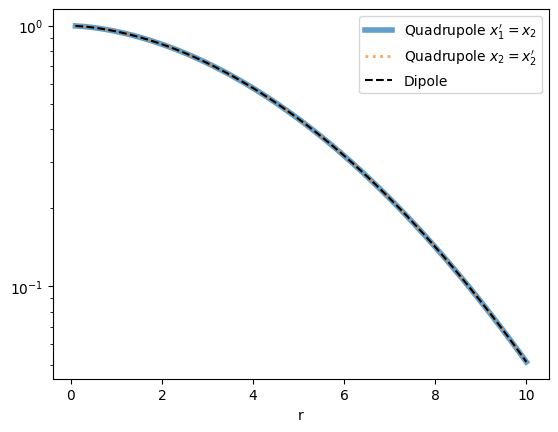

In [30]:
def TestCoinsidence(largenc=False):
    ''' Test limit where Q -> dipole '''

    x2p=np.array([1,2])
    x1p=[1.001,2.003]

    #print(Quadrupole([1,2],[3,4],x2p,x2p))

    x1=np.array([1,3])
    ru=np.array([np.sqrt(1/2),np.sqrt(1/2)])
    ru=np.array([0,1])
    rvals=np.linspace(0.1,10)
    x2 = [x1+ru*r for r in rvals]

    
    #q = np.vectorize(Quadrupole)(x1,x2,x2p,x1p)
    q = [Quadrupole(x1,x2[i],x2p,x1p, largeNc=largenc) for i in range(len(x2))]
    dip=DipoleS(rvals,log=False)


    eps=np.array([1e-8,1e-8])
    x2=np.array([4,1])
    # AT THE MOMENT COISIDENCE LIMIT WHERE x2=x2' does not work!
    q_x2px2 = [Quadrupole(x1, x2, x2+eps, x1+ru*r, largeNc=largenc) for r in rvals ]

    #  x1p approx x2p
    qlarge = [Quadrupole(x1,x1+ru*r ,x2p,x1p,largeNc=largenc) for r in rvals]

    
    plt.plot(rvals, q,label="Quadrupole $x_1'=x_2$",alpha=0.7,linewidth=4)
    plt.plot(rvals, q_x2px2,label="Quadrupole $x_2=x_2'$",alpha=0.7,linewidth=2,linestyle="dotted")
    plt.plot(rvals,dip,linestyle="dashed",label="Dipole",color="black")
   
    plt.xlabel("r")
    plt.legend()
    plt.yscale("log")

TestCoinsidence(largenc=False)

### Line

In [31]:
def Line(r):
    Nc=3
    dip = DipoleS(r,log=False)
    return (Nc+1)/2.*(dip)**(2*(Nc+2.)/(Nc+1.)) - (Nc-1.)/2.*(dip)**(2*(Nc-2.)/(Nc-1.))

Test Line configuration

Recall 
$$Q(x_1,x_2,x_2',x_1') = \frac{1}{N_c} Tr(V(x_1)V^\dagger(x_1')V(x_2')V^\dagger(x_2))$$

Lappi, Dumitru, Schenke, Venugopalan have
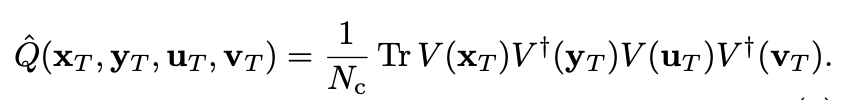


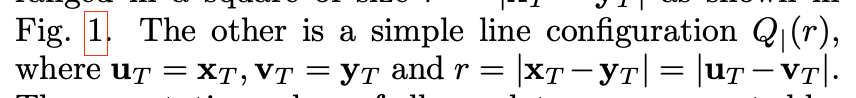

Note: $V$'s at same coordinate, and $V^\dagger$ at the same coordinate. In our definition, this corresponds to $x_1 = x_2', x_1' = x_2$ and $r=|x_1 - x_1'| = |x_2 - x_2'|$. I.e. $Q(x_1, x_2, x_1, x_2)$

0.9999999937794841
0.992352035955314
0.975113633124375
0.950763464849766
0.9202479742638028
0.8840829035549409
0.8425957436622773
0.7960159998991998
0.7445157864899599
0.6882299173383837
0.6272662417559656
0.5617108469307841
0.4916303352970848
0.41707231638074793
0.3380647363141298
0.254614400584537
0.16670489834546487
0.07429405105798081
-0.022689044288289884
-0.12434734132364644
-0.230819527577089
-0.3422840705285921
-0.4589636466402869
-0.5811299864085695
-0.7091091806148915
-0.8432875050884856
-0.9841178339472514
-1.132126724872263
-1.2879222748695631
-1.4522028615410554
-1.6257669034990077
-1.809523794623173
-2.0045061908328203
-2.2118838554506923
-2.4329793006766804
-2.6692854988705155
-2.922485979089619
-3.1944776726078103
-3.4873969270907343
-3.8036491740638683
-4.1459428098573925
-4.517327938212169
-4.921240725382529
-5.361554238475833
-5.84263677800443
-6.369418879839058
-6.947470354268933
-7.583088955825835
-8.283402543017013
-9.056486899392075


/tmp/ipykernel_842295/2902437634.py:48: RuntimeWarning: divide by zero encountered in scalar divide
  r = f1/f2


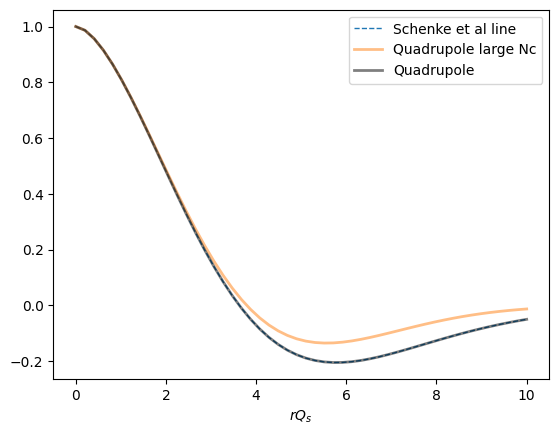

In [32]:
def PlotLineComparison():
    #Schenke: uT = xT,vT = yT and r= |xT−yT|= |uT−vT|.

    rvals=np.linspace(1e-4,10)
    eps=np.array([1e-5,1e-5])

    x=np.array([1,0])


    unitv = -np.array([1,0])


    #

    # TODO This works!?
    #
         
    # Note: our Quadrupole is defined as 
    #S(x1,x2,x2p,x1p)= tr V(x1)V^d(x1p)V(x2p)V^d(x2)
    # Line configuration in Lappi, Schenke: tv V(x)V^d(y)V(x)V^d(y)

    # So this line configuration corresponds to
    # x1=x
    # x1p = y
    # x2p=x
    # x2 = y
    # i.e. S(x,y,x,y)
    #
    # y = x + v*r where |v|=1

    q = [Quadrupole(x, x+unitv*r,  x,x+unitv*r, largeNc=False) for r in rvals]
    
    # Eps to avoid 0/0 
    q_largenc = [Quadrupole(x, x+unitv*r-eps, x+eps, x+unitv*r, largeNc=True) for r in rvals]
    dip=Line(rvals )



   
    plt.plot(rvals,dip,label="Schenke et al line",alpha=1,linewidth=1,linestyle="dashed")
    plt.plot(rvals, q_largenc,label="Quadrupole large Nc",alpha=0.5,linewidth=2)
    plt.plot(rvals,q,label="Quadrupole",alpha=0.5,linewidth=2,color="black")

    #plt.plot(rvals,q_test,label="quad square",alpha=0.5,linewidth=2,color="red")

    #plt.plot(rvals,DipoleS(rvals,log=False)**2,linestyle="dotted",label="Naive")

    plt.legend()

    plt.xlabel(r"$rQ_s$")

    return rvals,q

dipr,quad=PlotLineComparison()
    

### Square

In [36]:
def Square(r):
    dip = DipoleS(r,log=False)  
    diproot2 = DipoleS(np.sqrt(2)*r,log=False)
    return dip**2*((Nc+1.)/2*(dip/diproot2)**(2/(Nc+1)) - (Nc-1)/2*(diproot2/dip)**(2/(Nc-1)))

def quadrupole_uu(u, up, z, alpha):
    x1  = np.array([(1 - z) * u, 0])
    x2  = np.array([-z * u, 0])
    x1p = np.array([(1 - z) * up*np.cos(alpha), (1 - z) * up*np.sin(alpha)])
    x2p = np.array([-z * up*np.cos(alpha), -z*up*np.sin(alpha)])

    return Quadrupole(x1, x2, x2p, x1p, largeNc=False)


In [ ]:
def PlotSquareComparison():


    rvals=np.linspace(1e-4,10)
    eps=np.array([1e-12,1e-12])

    

    # Note: our Quadrupole is defined as 
    #S(x1,x2,x2p,x1p)= tr V(x1)V^d(x1p)V(x2p)V^d(x2)
    #Lappi x,y,u,v

    # x1,x1p,x2p,x2
    
    x1=np.array([1,0])

    unitv_1 = np.array([1,0])
    unitv_2 = np.array([0,1])+eps

    z = 1-0.00001
    z1 = 1+np.sqrt(2)
    z2 = 1-np.sqrt(2)
    alpha = 0.01*np.pi

    q = [Quadrupole(x1, x1 + unitv_2*r , x1+unitv_1*r + unitv_2*r , x1 + unitv_1*r) for r in rvals]
    q_largenc = [Quadrupole(x1+eps,  x1 + unitv_2*r  , x1+unitv_1*r + unitv_2*r-eps ,x1+unitv_1*r+eps, largeNc=True) for r in rvals]
    dip=Square(rvals )

    #print(q,dip)
   
    plt.plot(rvals,dip,label="Schenke et al square",alpha=0.7,linewidth=1,linestyle="dashed")
    plt.plot(rvals, q_largenc,label="Quadrupole large Nc",alpha=0.7,linewidth=2)
    plt.plot(rvals,q,label="Quadrupole",alpha=0.4,linewidth=2,color="black")
    

    #plt.plot(dipr,quad,linestyle="dotted",label="Line quadrupole")

    #plt.plot(rvals,DipoleS(rvals,log=False)**2,linestyle="dotted",label="Naive")

    plt.legend()

    plt.xlabel(r"$rQ_s$")

PlotSquareComparison()

SyntaxError: invalid syntax (3041090275.py, line 27)